In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Lire le CSV avec le bon séparateur
df = pd.read_csv(r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv",sep=";")

# Colonnes numériques à nettoyer
colonnes_numeriques = ["Nombre de Titres", "Montant", "Echéance", "Taux"]

# Nettoyage de ces colonnes
for col in colonnes_numeriques:
    df[col] = (
        df[col]
        .str.replace(r"\s+", "", regex=True)  # supprime les espaces
        .str.replace(",", ".")               # remplace virgule par point
        .replace("-", np.nan)                # remplace tirets par NaN
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")  # convertit en float

# Vérification
df.dtypes


dataloadingdate      object
ISIN                 object
Libellé              object
Nombre de Titres    float64
Montant             float64
Echéance            float64
Taux                float64
dtype: object

In [105]:
df.describe

<bound method NDFrame.describe of       dataloadingdate          ISIN                Libellé  Nombre de Titres  \
0          01/07/2025  TN0008000739  BTA 7,4% Fevrier 2030           1459.00   
1          01/07/2025  TN0008000739  BTA 7,4% Fevrier 2030            291.00   
2          01/07/2025  TNMCPXLL1EE2  EMP NAT 2023 T4 CB TV          50000.00   
3          01/07/2025  TNMCPXLL1EE2  EMP NAT 2023 T4 CB TV          10000.00   
4          01/07/2025  TN0008000606    BTA 6,7% Avril 2028           5660.00   
...               ...           ...                    ...               ...   
19885      31/12/2024  TN0008000812    BTA 7,5% 13/12/2028            215.00   
19886      31/12/2024  TNX0K9990B08  EMP NAT 2024 T2 CB TF           5243.00   
19887      31/12/2024  TNX0K9990B08  EMP NAT 2024 T2 CB TF          28288.00   
19888      31/12/2024  TNX0K9990B08  EMP NAT 2024 T2 CB TF          48701.00   
19889      31/12/2024  TNX0K9990B08  EMP NAT 2024 T2 CB TF           4715.00   

     

In [107]:
df.isna().sum()

dataloadingdate     0
ISIN                0
Libellé             0
Nombre de Titres    1
Montant             1
Echéance            1
Taux                1
dtype: int64

In [74]:
df

,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",1459.00,1.50,62.00,7.60
1,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",291.00,0.30,183.00,7.50
2,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.00,5.00,13.00,8.60
3,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.00,1.00,7.00,8.60
4,01/07/2025,TN0008000606,"BTA 6,7% Avril 2028",5660.00,5.74,31.00,9.10
...,...,...,...,...,...,...,...
19885,31/12/2024,TN0008000812,"BTA 7,5% 13/12/2028",215.00,0.20,50.00,9.00
19886,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,5243.00,0.56,15.00,7.49
19887,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,28288.00,3.00,31.00,8.99
19888,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,48701.00,5.17,31.00,8.99


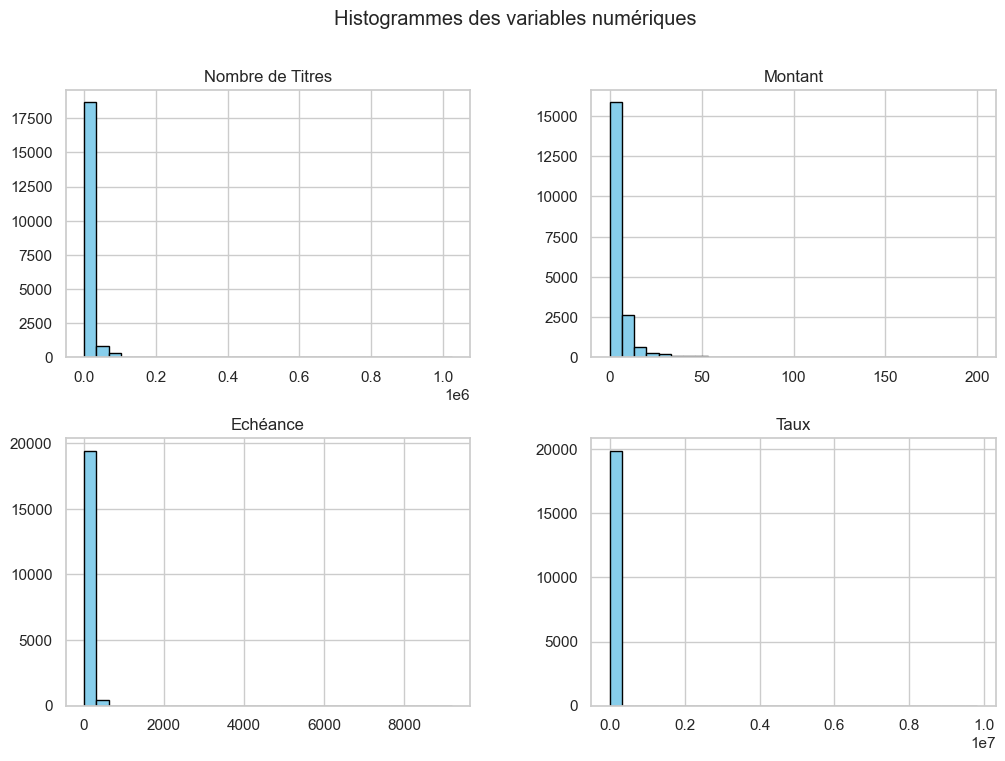

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

colonnes_num = ["Nombre de Titres", "Montant", "Echéance", "Taux"]

df[colonnes_num].hist(bins=30, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle("Histogrammes des variables numériques")
plt.show()


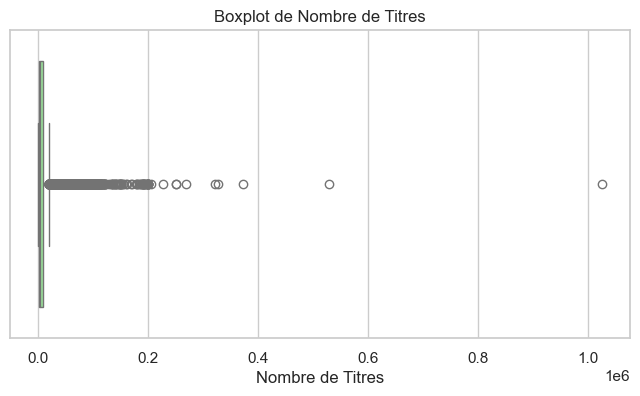

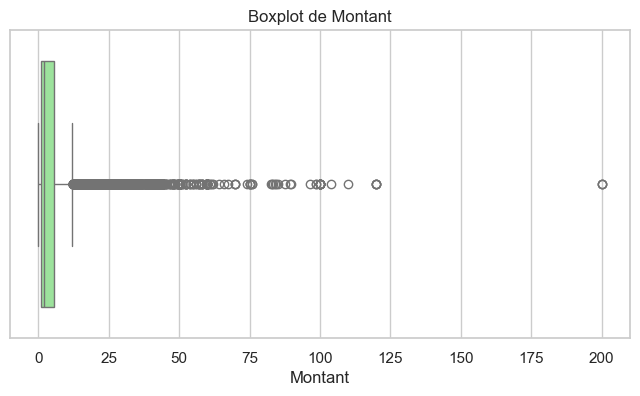

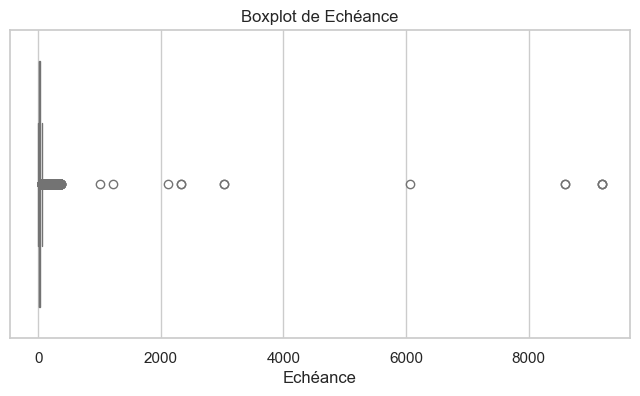

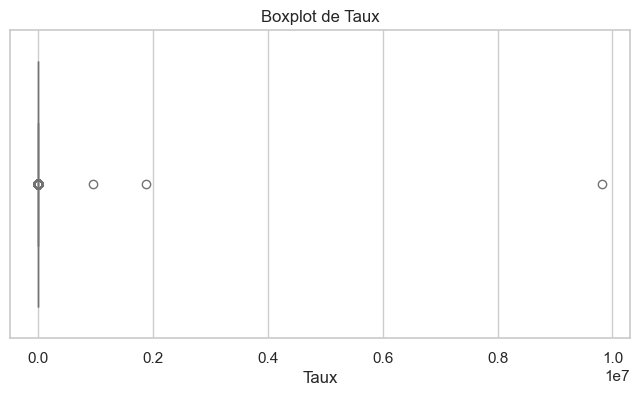

In [76]:
for col in colonnes_num:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot de {col}")
    plt.show()


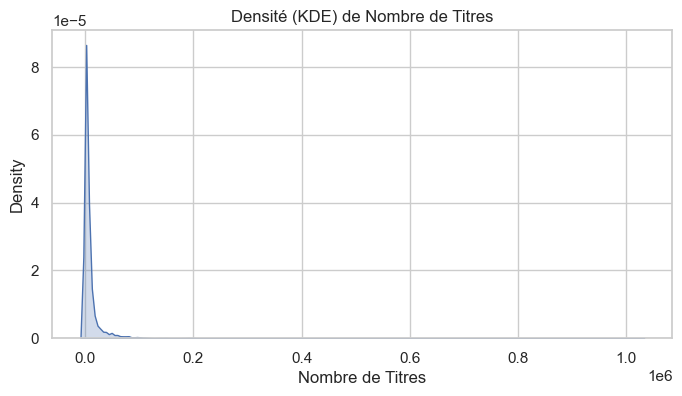

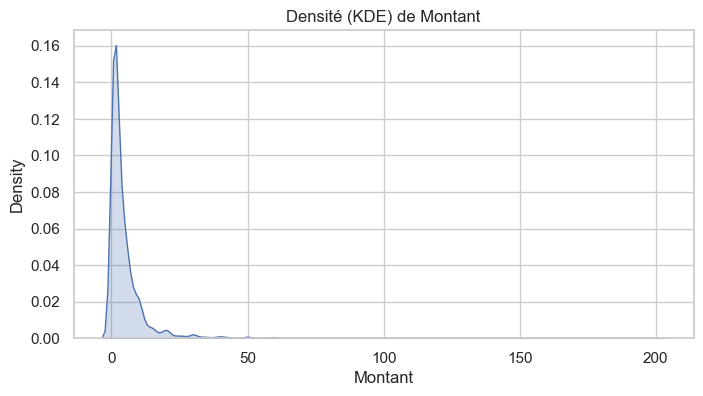

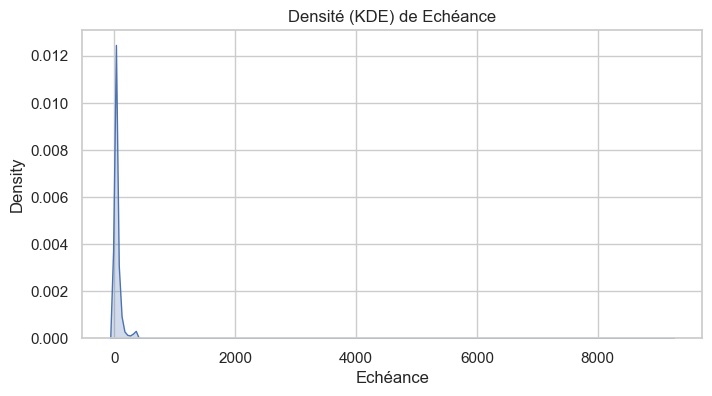

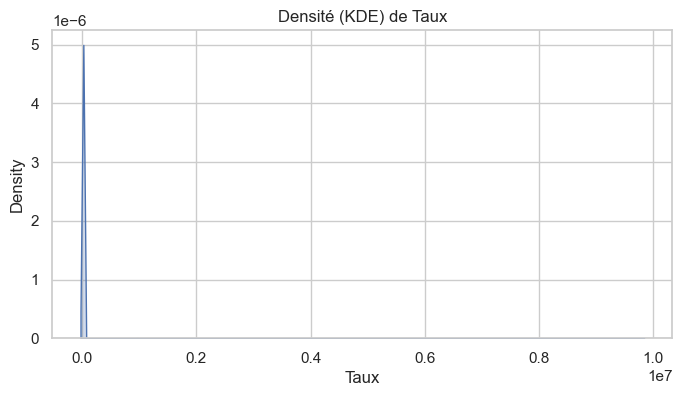

In [77]:
for col in colonnes_num:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Densité (KDE) de {col}")
    plt.show()


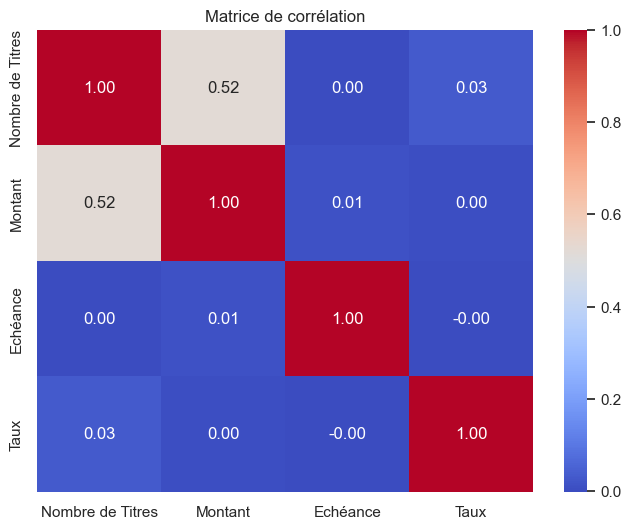

In [78]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[colonnes_num].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de corrélation")
plt.show()


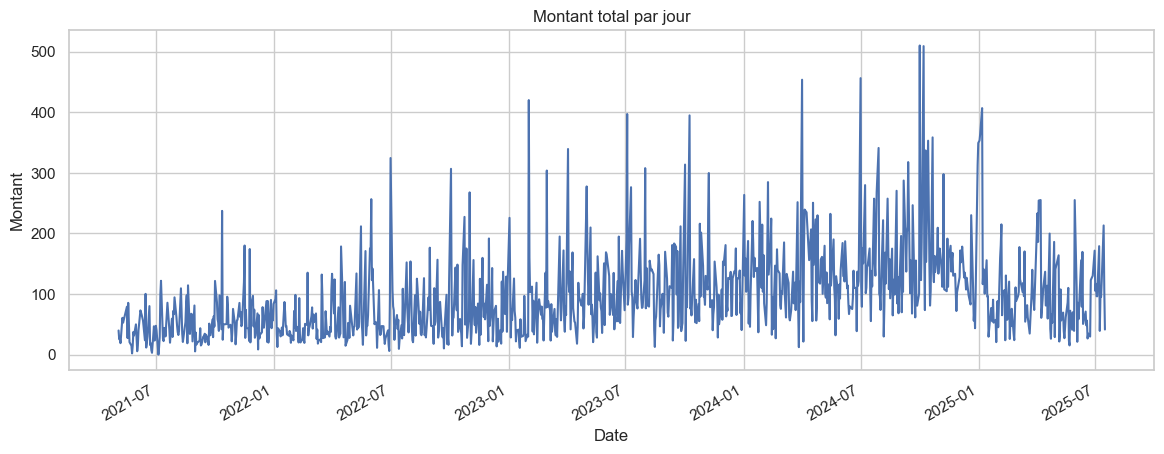

In [95]:
df['dataloadingdate'] = pd.to_datetime(df['dataloadingdate'], dayfirst=True, errors='coerce')

df.groupby('dataloadingdate')["Montant"].sum().plot(figsize=(14, 5))
plt.title("Montant total par jour")
plt.ylabel("Montant")
plt.xlabel("Date")
plt.show()


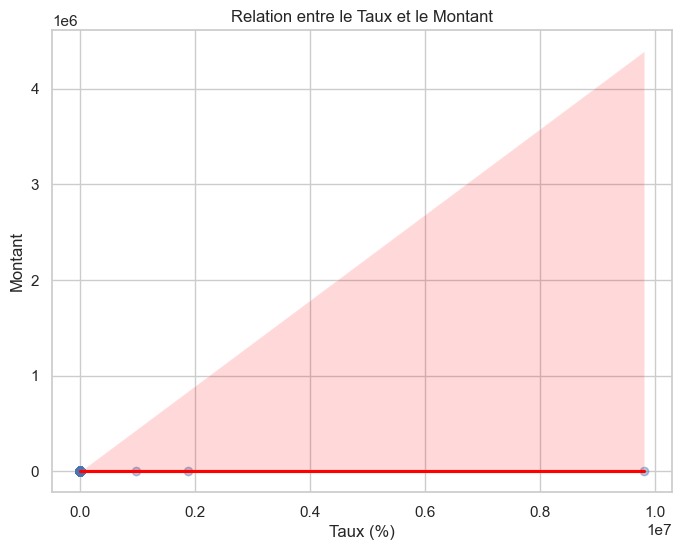

Corrélation entre Taux et Montant : 0.003


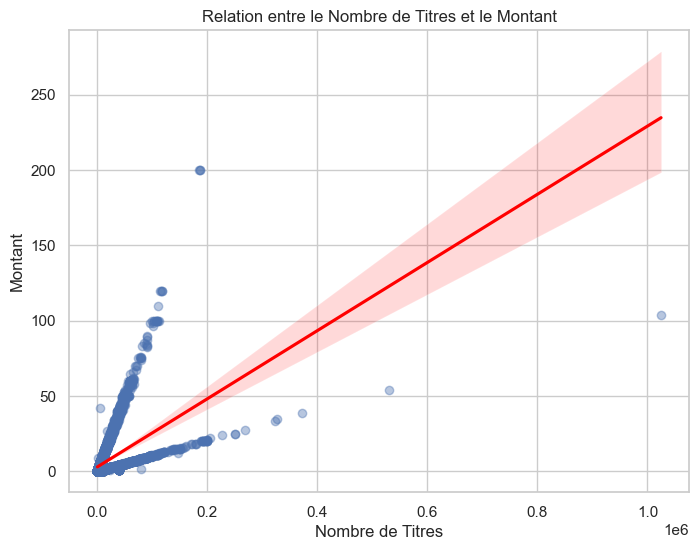

Corrélation entre Nombre de Titres et Montant : 0.519


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# === 1. Montant vs Taux ===
plt.figure(figsize=(8, 6))
sns.regplot(x='Taux', y='Montant', data=df, scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.title("Relation entre le Taux et le Montant")
plt.xlabel("Taux (%)")
plt.ylabel("Montant")
plt.grid(True)
plt.show()

# Corrélation
corr1, _ = pearsonr(df['Taux'].dropna(), df['Montant'].dropna())
print(f"Corrélation entre Taux et Montant : {corr1:.3f}")

# === 2. Montant vs Nombre de Titres ===
plt.figure(figsize=(8, 6))
sns.regplot(x='Nombre de Titres', y='Montant', data=df, scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.title("Relation entre le Nombre de Titres et le Montant")
plt.xlabel("Nombre de Titres")
plt.ylabel("Montant")
plt.grid(True)
plt.show()

# Corrélation
corr2, _ = pearsonr(df['Nombre de Titres'].dropna(), df['Montant'].dropna())
print(f"Corrélation entre Nombre de Titres et Montant : {corr2:.3f}")


In [81]:
df["dataloadingdate"] = pd.to_datetime(df["dataloadingdate"], dayfirst=True, errors='coerce')


In [82]:
montants_par_jour = df.groupby("dataloadingdate")["Montant"].sum()
print(montants_par_jour)


dataloadingdate
2021-05-04    39.77
2021-05-05    25.25
2021-05-06    27.37
2021-05-07    18.89
2021-05-10    60.67
              ...  
2025-07-10    95.15
2025-07-11   121.49
2025-07-14   213.07
2025-07-15   105.52
2025-07-16    41.40
Name: Montant, Length: 1049, dtype: float64


In [83]:
# Créer une colonne "mois"
df["mois"] = df["dataloadingdate"].dt.to_period("M")

# Groupe par mois
montants_par_mois = df.groupby("mois")["Montant"].sum()
print(montants_par_mois)


mois
2021-05    642.38
2021-06    806.54
2021-07    985.08
2021-08   1083.97
2021-09    689.75
2021-10   1310.77
2021-11   1457.95
2021-12   1140.29
2022-01    932.04
2022-02    999.91
2022-03   1109.10
2022-04   1266.70
2022-05   1554.11
2022-06   1311.57
2022-07   1439.96
2022-08   1631.17
2022-09   1244.66
2022-10   1964.65
2022-11   1745.78
2022-12   1585.72
2023-01   1308.39
2023-02   1877.07
2023-03   1796.68
2023-04   1809.48
2023-05   2252.23
2023-06   1962.10
2023-07   2472.63
2023-08   2477.24
2023-09   2160.55
2023-10   2691.89
2023-11   2385.85
2023-12   2286.52
2024-01   3049.30
2024-02   2572.93
2024-03   1991.54
2024-04   3140.31
2024-05   2573.03
2024-06   2144.44
2024-07   3684.07
2024-08   2662.28
2024-09   3130.67
2024-10   4460.27
2024-11   2849.76
2024-12   2874.22
2025-01   2654.92
2025-02   1782.83
2025-03   1726.59
2025-04   2403.05
2025-05   1490.40
2025-06   1602.51
2025-07   1304.28
Freq: M, Name: Montant, dtype: float64


In [84]:
df["annee"] = df["dataloadingdate"].dt.year

montants_par_annee = df.groupby("annee")["Montant"].sum()
print(montants_par_annee)


annee
2021    8116.72
2022   16785.38
2023   25480.64
2024   35132.82
2025   12964.59
Name: Montant, dtype: float64
